# Проект: Анализ Brazilian E-Commerce Public Dataset by Olist
Ссылка на бд в kaggle: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
## Цель проекта
E-commerce платформa Olist - платформа для электронной коммерции, предназначенная для малого и среднего бизнеса. Она работает как маркетплейс: продавцы могут размещать свои продукты и услуги, а клиенты - просматривать и покупать их онлайн
Цель проекта - провести комплексный анализ e-commerce платформы Olist, выявить закономерности продаж, сезонность спроса, особенности логистики и определить зоны роста бизнеса на основе данных.

## Подлючение библиотек

In [1]:
import psycopg2
from sqlalchemy import create_engine
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


## Подключение к бд

In [2]:
user = "postgres"
password = "qwerty"
host = "localhost"
port = "5432"
database = "pet_project"

engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}"
)

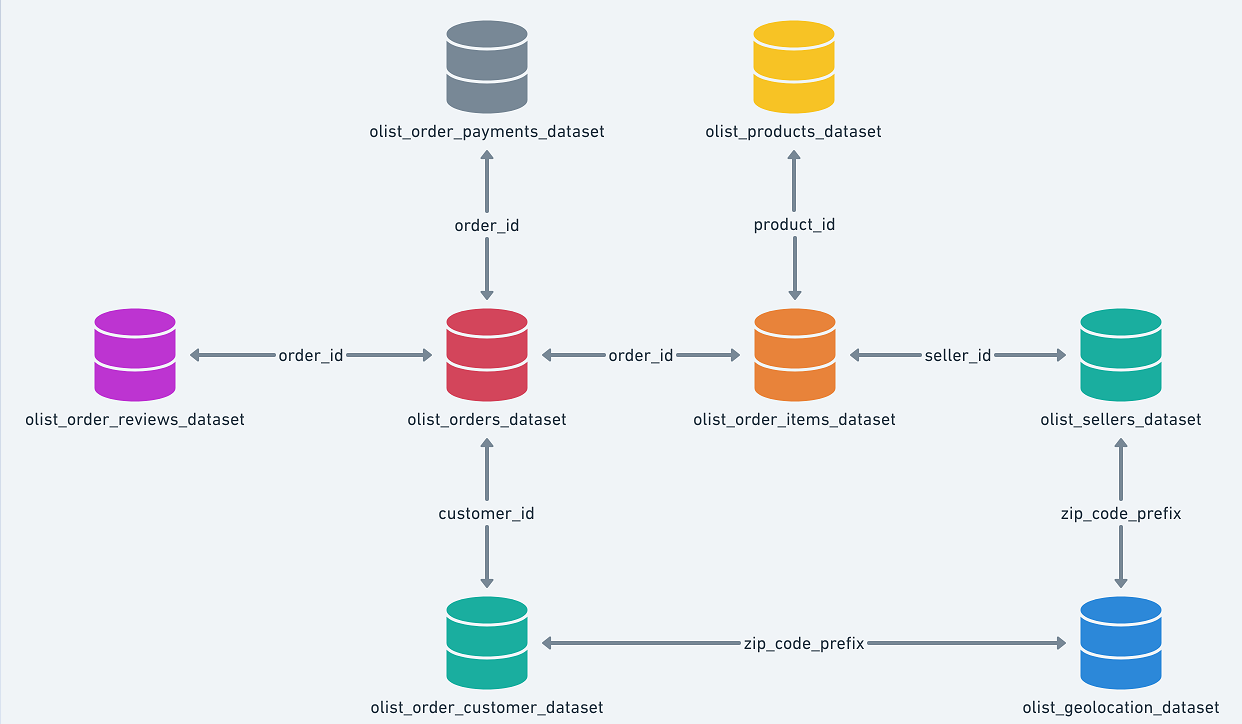

In [3]:
# --- Получение списка таблиц ---
query_tables = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public';
"""

tables_df = pd.read_sql(query_tables, engine)
tables = tables_df['table_name'].tolist()

print("Таблицы:", tables, "\n")


# --- Функции для анализа таблиц ---
def get_dataframe(table):
    """Загружает таблицу из PostgreSQL в pandas DataFrame."""
    query = f'SELECT * FROM "{table}"'
    return pd.read_sql(query, engine)


def analyze_table(table):
    print(f"===== Анализ таблицы: {table} =====")
    
    df = get_dataframe(table)

    # Размер таблицы
    print(f"Количество строк: {len(df)}")

    # Дубликаты
    duplicates_count = df.duplicated().sum()
    print(f"Количество дубликатов: {duplicates_count}")

    # Пропуски
    null_counts = df.isnull().sum()
    print("\nПропуски по столбцам:")
    print(null_counts[null_counts > 0])
    
    print("\n")


# --- Запуск анализа ---
for table in tables:
    analyze_table(table)

Таблицы: ['olist_customers', 'olist_geolocation', 'olist_orders', 'olist_order_items', 'olist_order_payments', 'olist_products', 'olist_sellers', 'product_category_name_translation', 'olist_order_reviews_raw'] 

===== Анализ таблицы: olist_customers =====
Количество строк: 99441
Количество дубликатов: 0

Пропуски по столбцам:
Series([], dtype: int64)


===== Анализ таблицы: olist_geolocation =====
Количество строк: 1000163
Количество дубликатов: 261831

Пропуски по столбцам:
Series([], dtype: int64)


===== Анализ таблицы: olist_orders =====
Количество строк: 99441
Количество дубликатов: 0

Пропуски по столбцам:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64


===== Анализ таблицы: olist_order_items =====
Количество строк: 112650
Количество дубликатов: 0

Пропуски по столбцам:
Series([], dtype: int64)


===== Анализ таблицы: olist_order_payments =====
Количество строк: 103886
Количество дубликатов: 0

Пропу

#  Data Dictionary Olist E-Commerce Dataset

Ниже приведено описание всех таблиц и полей, используемых в проекте.  
Для каждой таблицы указаны: назначение, ключи, типы данных и смысл полей.

---

## 1. olist_customers

**Описание:** информация о покупателях  
**Количество строк:** 99441
**Первичный ключ (PK):** `customer_id`
**Количество дубликатов:** 0
**Количество пропусков:** 0

| Поле | Тип | Описание | Ключ |
|------|------|----------|------|
| customer_id | text | внутренний ID покупателя | PK |
| customer_unique_id | text | реальный уникальный пользователь (несколько заказов) | |
| customer_zip_code_prefix | int4 | почтовый префикс | логический FK → geolocation |
| customer_city | text | город | |
| customer_state | text | штат | |

---

## 2. olist_geolocation

**Описание:** координаты для почтовых префиксов  
**Количество строк:**  1 000 163
 В таблице много дубликатов - это норма. PK отсутствует.
**Количество дубликатов:** 261831 !Один ZIP-код имеет много точек → в геолокации хранится сетка координат!
**Количество пропусков:** 0

| Поле | Тип | Описание |
|------|------|----------|
| geolocation_zip_code_prefix | int4 | префикс ZIP |
| geolocation_lat | float8 | широта |
| geolocation_lng | float8 | долгота |
| geolocation_city | text | город |
| geolocation_state | text | штат |

---

## 3. olist_orders

**Описание:** информация о заказах
**Количество строк:** 99441
**PK:** `order_id`
**Количество дубликатов:** 0
**Количество пропусков:** 
Пропуски по столбцам:
- order_approved_at                 160 - заказ не подвтержден? Должны быть и пустые поля у других таких строк
- order_delivered_carrier_date     1783 - заказ в статусе подвтержден, но еще не передан курьеру
- order_delivered_customer_date    2965 - заказ ещё не доставлен клиенту
## Аномалии
- дата доставки раньше даты покупки - нужно проверить
- статус `delivered`, но delivery_date пустой - ошибка данных: добавить столбец доставлен ли заказ действительно

| Поле | Тип | Описание | Ключ |
|------|------|----------|------|
| order_id | text | ID заказа | PK |
| customer_id | text | ID покупателя | FK → customers |
| order_status | text | статус заказа | |
| order_purchase_timestamp | timestamp | дата оформления | |
| order_approved_at | timestamp | подтверждение заказа | |
| order_delivered_carrier_date | timestamp | передан курьеру | |
| order_delivered_customer_date | timestamp | доставлен клиенту | |
| order_estimated_delivery_date | timestamp | обещанная дата | |

---

## 4. olist_order_items
**Количество строк:** 112650
**Описание:** позиции внутри заказа  
**Составной PK:** (`order_id`, `order_item_id`)
**Количество дубликатов:** 0
**Количество пропусков:** 0
| Поле | Тип | Описание | Ключ |
|------|------|----------|------|
| order_id | text | ID заказа | FK → orders |
| order_item_id | int4 | номер позиции в заказе | часть PK |
| product_id | text | ID товара | FK → products |
| seller_id | text | ID продавца | FK → sellers |
| shipping_limit_date | timestamp | дедлайн отгрузки | |
| price | float8 | цена товара | |
| freight_value | float8 | стоимость доставки | |
## Аномалии
- цена может быть 0 (редко - возможно ошибки входа)
- freight_value = 0 - означает бесплатную доставку

## Решения по нормализации
- Цена = 0 → оставить, но пометить как возможные ошибки (редко)
- freight_value = 0 оставляем
---

## 5. olist_order_payments

**Описание:** информация о платежах  
**Количество строк:** 103886
**Составной PK:** (`order_id`, `payment_sequential`)
**Количество дубликатов:** 0
**Количество пропусков:** 0

| Поле | Тип | Описание | Ключ |
|------|------|----------|------|
| order_id | text | ID заказа | FK → orders |
| payment_sequential | int4 | номер платежа | часть PK |
| payment_type | text | тип оплаты | |
| payment_installments | int4 | количество взносов | |
| payment_value | float8 | сумма платежа | |

## Аномалии
- частичная предоплата → несколько строк на заказ
- рассрочка (installments) может быть > 1 - нормально
- payment_value иногда суммируется НЕ в точности до общей суммы заказа (округления)

## Решения по нормализации
- Оставить данные как есть.
- При анализе смотреть сумму по заказу: SUM(payment_value)

---

## 6. olist_order_reviews_raw
**Количество строк:** 99224
**Описание:** отзывы покупателей  
**PK:** `review_id`
**Количество дубликатов:** 0
**Пропуски по столбцам:**
review_comment_title      87656
review_comment_message    58247
## Аномалии
Пропуски в описании отзыва - норма, люди воздержались от ответа.

| Поле | Тип | Описание | Ключ |
|------|------|----------|------|
| review_id | text | ID отзыва | PK |
| order_id | text | ID заказа | FK → orders |
| review_score | int4 | оценка (1–5) | |
| review_comment_title | text | заголовок отзыва | |
| review_comment_message | text | текст отзыва | |
| review_creation_date | timestamp | дата создания | |
| review_answer_timestamp | timestamp | дата ответа системы | |


## Решения по нормализации
- Пропуски НЕ заполнять.
- Для анализа NLP можно заменить пустые строки на `"No review text"`.
---

## 7. olist_products
**Количество строк:** 32951
**Описание:** карточки товаров  
**PK:** `product_id`
**Количество дубликатов:** 0
**Пропуски по столбцам:**
- product_category_name         610
- product_name_length           610
- product_description_length    610
- product_photos_qty            610
- product_weight_g                2
- product_length_cm               2
- product_height_cm               2
- product_width_cm                2

| Поле | Тип | Описание | Ключ |
|------|------|----------|------|
| product_id | text | ID товара | PK |
| product_category_name | text | категория | логический FK → translation |
| product_name_length | int4 | длина названия | |
| product_description_length | int4 | длина описания | |
| product_photos_qty | int4 | число фото | |
| product_weight_g | int4 | вес | |
| product_length_cm | int4 | длина | |
| product_height_cm | int4 | высота | |
| product_width_cm | int4 | ширина | |
 
## Аномалии
- 2 товара с пустыми размерами/весом → ошибки данных
- 610 товаров без категории → распространённая проблема Olist

## Решения по нормализации
- Пропуски категории → заменить на `"unknown_category"`
- Пропуски размеров → заменить **медианой категории** ИЛИ удалить товары, если они нигде не используются
- Проверить: есть ли эти товары в order_items
---

## 8. olist_sellers
**Количество строк:** 3095
**Описание:** продавцы  
**PK:** `seller_id`
**Количество дубликатов:** 0
**Количество пропусков:** 0


| Поле | Тип | Описание | Ключ |
|------|------|----------|------|
| seller_id | text | ID продавца | PK |
| seller_zip_code_prefix | int4 | почтовый префикс | логический FK → geolocation |
| seller_city | text | город | |
| seller_state | text | штат | |

---

## 9. product_category_name_translation
**Количество строк:** 71
**Описание:** перевод категорий  
**PK:** `product_category_name`
**Количество дубликатов:** 0
**Количество пропусков:** 0


| Поле | Тип | Описание | Ключ |
|------|------|----------|------|
| product_category_name | text | категория (pt) | PK |
| product_category_name_english | text | перевод | |
## Аномалии
В products есть категории, которых нет в переводах.

## Решения по нормализации
- Связь один-ко-многим НЕ строгая: категорий в products больше, чем переводов.
- Заполнять отсутствующие переводы можно как `"unknown"`.
---
 ## Итог: какие действия требуют внимания

| Таблица | Нужно вмешательство? | Действия |
|---------|----------------------|----------|
| customers | ❌ | всё хорошо |
| geolocation | ❌ | дубликаты - норма |
| orders | ✔ | добавить флаги, проверить логические даты |
| order_items | ❌ | всё хорошо |
| order_payments | ❌ | мелкие аномалии |
| reviews | ❌ | пропуски - норма |
| **products** | **✔✔✔** | основная таблица, требующая очистки |
| sellers | ❌ | всё хорошо |
| category_translation | ❌ | всё хорошо |


 # Data Cleaning & Normalization
 
### Преобразование таблиц в dataframes

В этом разделе проводится очистка и нормализация ключевых таблиц:
- products
- orders

Результатом являются датафреймы `products_clean` и `orders_clean`,
которые далее используются для аналитических задач.


In [4]:
# список таблиц
tables = [
    "olist_customers",
    "olist_geolocation",
    "olist_orders",
    "olist_order_items",
    "olist_order_payments",
    "olist_order_reviews_raw",
    "olist_products",
    "olist_sellers",
    "product_category_name_translation"
]

dfs = {} 

for table in tables:
    dfs[table] = pd.read_sql(f"SELECT * FROM {table}", engine)

# теперь датафрейм products доступен как:
products_clean = dfs["olist_products"]
orders = dfs["olist_orders"]

## TABLE PRODUCTS
## 1. Пропуски product_category_name
Решение: заменить на "unknown_category"

In [5]:
products_clean['product_category_name'] = products_clean['product_category_name'].fillna('unknown_category')
products_clean[products_clean.values =='unknown_category']

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,unknown_category,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,unknown_category,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,unknown_category,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,unknown_category,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,unknown_category,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,unknown_category,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,unknown_category,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,unknown_category,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,unknown_category,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


## 2. Пропуски в: 
- product_name_length
- product_description_length
- product_photos_qty

Решение: заменить на 0

In [6]:
products_clean = products_clean.fillna(0)

##  3. Пропуски в габаритах и весе:
Изменим пропуски на медианные значения данных категорий
- product_weight_g
- product_length_cm
- product_height_cm
- product_width_cm

In [7]:
mean_weight = products_clean.loc[products_clean['product_category_name'] == 'bebes', 'product_weight_g'].mean()
mean_length = products_clean.loc[products_clean['product_category_name'] == 'bebes', 'product_length_cm'].mean()
mean_height = products_clean.loc[products_clean['product_category_name'] == 'bebes', 'product_height_cm'].mean()
mean_width = products_clean.loc[products_clean['product_category_name'] == 'bebes', 'product_width_cm'].mean()

In [8]:
products_clean.loc[products_clean['product_id'] == '09ff539a621711667c43eba6a3bd8466',['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']] = [mean_weight, mean_length, mean_height, mean_width]
products_clean.loc[products_clean['product_id'] == '09ff539a621711667c43eba6a3bd8466']

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8582,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,3651.224157,37.106638,21.594124,28.686616


In [9]:
mean_weight = products_clean['product_weight_g'].mean()
mean_length = products_clean['product_length_cm'].mean()
mean_height = products_clean['product_height_cm'].mean()
mean_width = products_clean['product_width_cm'].mean()

In [10]:
products_clean.loc[products_clean['product_id'] == '5eb564652db742ff8f28759cd8d2652a',['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']] = [mean_weight, mean_length, mean_height, mean_width]
products_clean.loc[products_clean['product_id'] == '5eb564652db742ff8f28759cd8d2652a']

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
18852,5eb564652db742ff8f28759cd8d2652a,unknown_category,0.0,0.0,0.0,2276.445122,30.814334,16.937289,23.196191


## TABLE ORDERS
## 1. Новые флаги

In [11]:
orders['is_approved'] = orders['order_approved_at'].notna()
orders['is_shipped'] = orders['order_delivered_carrier_date'].notna()
orders['is_delivered'] = orders['order_delivered_customer_date'].notna()
orders['is_late'] = (
    orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']
)


## 2. Проверка аномалий


In [12]:
orders['anomaly_delivered_before_shipped'] = (
    (orders['order_delivered_customer_date'].notna()) &
    (orders['order_delivered_carrier_date'].notna()) &
    (orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date'])
)

orders['anomaly_shipped_before_approved'] = (
    (orders['order_delivered_carrier_date'].notna()) &
    (orders['order_approved_at'].notna()) &
    (orders['order_delivered_carrier_date'] < orders['order_approved_at'])
)

orders['anomaly_delivered_before_purchase'] = (
    (orders['order_delivered_customer_date'].notna()) &
    (orders['order_purchase_timestamp'].notna()) &
    (orders['order_delivered_customer_date'] < orders['order_purchase_timestamp'])
)


## 3. Cтолбцы с длительностью процессов

In [13]:
orders['time_to_approve'] = (
    orders['order_approved_at'] - orders['order_purchase_timestamp']
) #время до подтверждения
orders['time_to_ship'] = (
    orders['order_delivered_carrier_date'] - orders['order_approved_at']
) # время до отправки
orders['time_to_deliver'] = (
    orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']
) # время до доставки
orders['total_order_time'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
) # общее время заказа


In [14]:
orders_clean = orders
orders_clean

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered,is_late,anomaly_delivered_before_shipped,anomaly_shipped_before_approved,anomaly_delivered_before_purchase,time_to_approve,time_to_ship,time_to_deliver,total_order_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,True,True,False,False,False,False,0 days 00:10:42,2 days 08:47:45,6 days 01:30:13,8 days 10:28:40
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,True,True,False,False,False,False,1 days 06:42:50,0 days 11:06:33,12 days 00:56:45,13 days 18:46:08
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,True,True,False,False,False,False,0 days 00:16:34,0 days 04:54:37,9 days 04:16:29,9 days 09:27:40
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True,True,True,False,False,False,False,0 days 00:17:53,3 days 17:54:00,9 days 10:48:43,13 days 05:00:36
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True,True,True,False,False,False,False,0 days 01:01:50,0 days 21:26:05,1 days 22:30:28,2 days 20:58:23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,True,True,True,False,False,False,False,0 days 00:00:00,1 days 01:23:58,7 days 03:49:58,8 days 05:13:56
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,True,True,True,False,False,False,False,0 days 00:11:39,1 days 10:12:05,20 days 18:15:14,22 days 04:38:58
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,True,True,True,False,False,False,False,0 days 00:17:33,1 days 05:48:10,23 days 14:31:51,24 days 20:37:34
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,True,True,True,False,False,False,False,0 days 00:07:54,3 days 17:58:42,13 days 07:57:51,17 days 02:04:27


In [15]:
orders_clean['anomaly_delivered_before_shipped'].unique()
orders_clean['anomaly_delivered_before_shipped'].loc[orders_clean['anomaly_delivered_before_shipped'] == True].count()

np.int64(23)

In [16]:
orders_clean['has_anomaly'] = (
    orders_clean['anomaly_delivered_before_shipped']
    | orders_clean['anomaly_shipped_before_approved']
    | orders_clean['anomaly_delivered_before_purchase']
)


In [17]:
orders_clean['has_anomaly'].value_counts()

has_anomaly
False    98059
True      1382
Name: count, dtype: int64

In [18]:
orders_clean['has_anomaly'].mean()

np.float64(0.013897688076346778)

## Выводы по предобработке данных

В ходе предобработки были выполнены следующие шаги:

- обработаны пропуски в данных
- выявлены и обработаны аномалии временных меток
- добавлены новые признаки (is_delivered, has_anomaly и др.)

В процессе анализа были выявлены заказы с некорректной последовательностью дат (доставка до подтверждения и др.).
Такие записи были помечены флагами аномалий, но не удалены из датасета, так как они могут отражать особенности логирования или ручных корректировок в системе.

# Анализ данных

# Глава Descriptive Analytics

В данном разделе аналитика выполнена только порседством функций Python и Pandas

# 1. Статусы заказов. Подсчет доли заказов и количества
* Количество заказов всего: 99441

In [19]:
orders_clean.groupby('order_status').size()

order_status
approved           2
canceled         625
created            5
delivered      96478
invoiced         314
processing       301
shipped         1107
unavailable      609
dtype: int64

## 1.1 Подсчет доли заказов

In [20]:
orders_status_mean = orders_clean['order_status'].value_counts(normalize=True) * 100

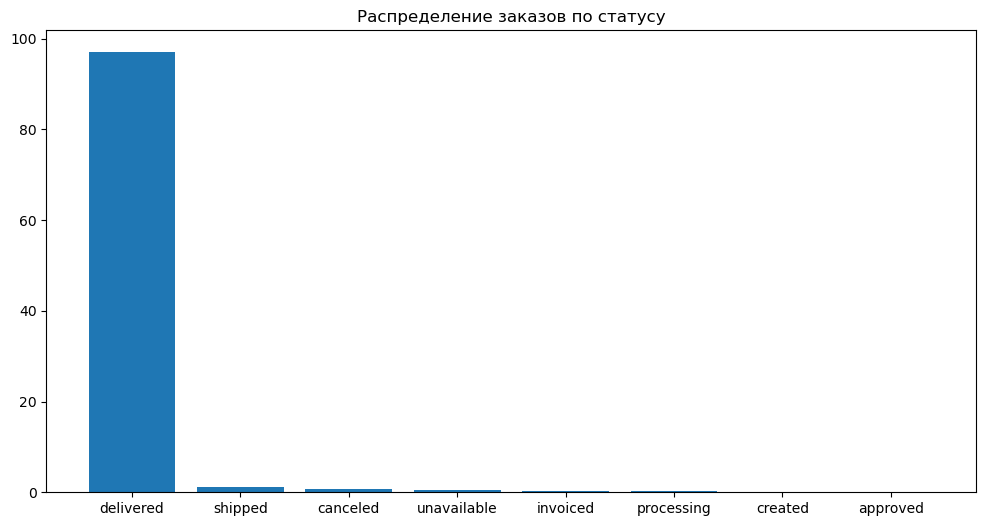

In [21]:
plt.figure(figsize=(12, 6))
plt.bar(orders_status_mean.index, orders_status_mean.values)
plt.title('Распределение заказов по статусу')
plt.show()


## 1.2 Распределение по временным меркам
1. Доставленные заказы

In [22]:
orders_clean['is_delivered'].loc[orders_clean['is_delivered'] == True].count()

np.int64(96476)

2. Заказы не доставленные, но отправленные

In [23]:
shipped_not_delivered = (
    (orders['is_shipped'] == True) &
    (orders['is_delivered'] == False)
)
shipped_not_delivered.loc[shipped_not_delivered == True].count()

np.int64(1183)

3. Заказы подтвержденные, но не отправленные

In [24]:
approved = (
    ( orders['is_approved'] == True) & 
    (orders['is_shipped'] == False) &
    (orders['is_delivered'] == False)
)
approved.loc[approved == True].count()

np.int64(1636)

### Выводы по статусам
Количество заказов со статусом 'shipped' меньше, чем количество заказов, имеющих дату передачи перевозчику. Это может означать, что часть заказов была отменена или переведена в статус unavailable после отправки, либо данные о статусе не были обновлены корректно.

# 2 Временная динамика заказов

## 2.1 Количество заказов по месяцам

Агрегация выполнена по дате создания заказа (`order_purchase_timestamp`).
Для подсчёта используется `.size()`, так как каждая строка соответствует одному заказу.


In [25]:
monthly_orders = orders_clean.groupby(pd.Grouper(key='order_purchase_timestamp', freq='ME')).size()
monthly_orders

order_purchase_timestamp
2016-09-30       4
2016-10-31     324
2016-11-30       0
2016-12-31       1
2017-01-31     800
2017-02-28    1780
2017-03-31    2682
2017-04-30    2404
2017-05-31    3700
2017-06-30    3245
2017-07-31    4026
2017-08-31    4331
2017-09-30    4285
2017-10-31    4631
2017-11-30    7544
2017-12-31    5673
2018-01-31    7269
2018-02-28    6728
2018-03-31    7211
2018-04-30    6939
2018-05-31    6873
2018-06-30    6167
2018-07-31    6292
2018-08-31    6512
2018-09-30      16
2018-10-31       4
Freq: ME, dtype: int64

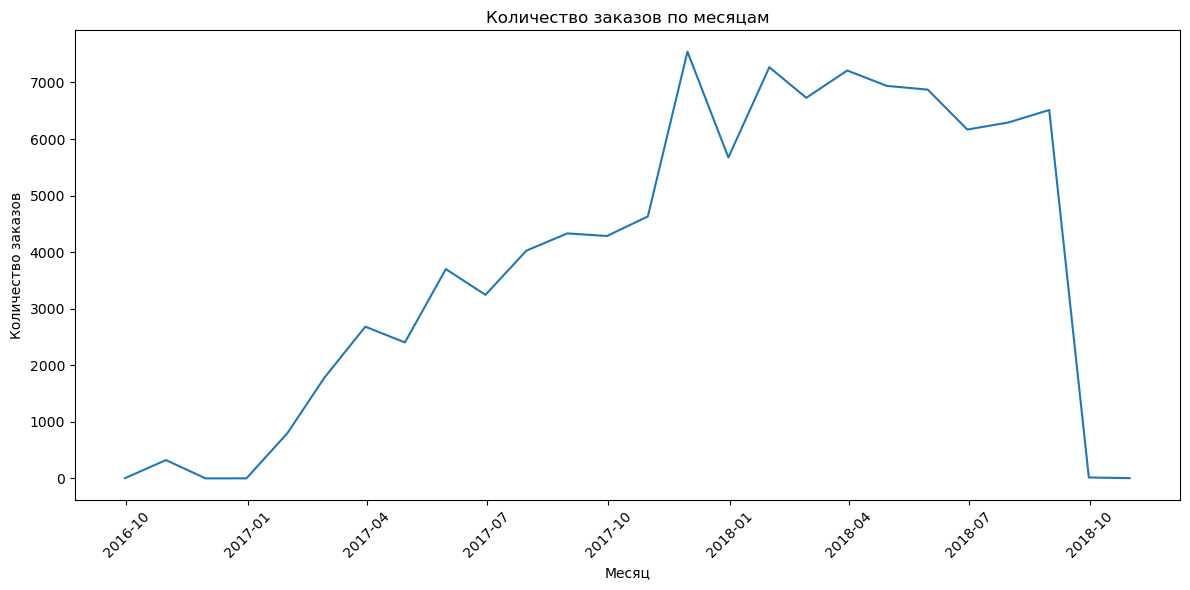

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_orders.index, monthly_orders.values)
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Благодаря данным графика замечаем, что в ноябре 2017 года прозошел пик продаж. Количество продаж по сравнению с предыдущими месяцами увеличился почти вдвое.
Почему в ноябре было больше заказов?
За счёт:
* определённых дней недели? например акция 11.11
* конкретных часов?


## 2.2 Анализ самого пикового месяца для компании - ноябрь 2017
### Анализ по дням недели

In [27]:
novembers_orders = orders_clean[
    (orders_clean['order_purchase_timestamp'].dt.month == 11) &
    (orders_clean['order_purchase_timestamp'].dt.year == 2017)
].copy()


In [28]:
novembers_orders['weekday'] = novembers_orders['order_purchase_timestamp'].dt.day_name()

In [29]:
novembers_orders_mean = novembers_orders.groupby('weekday').size()
novembers_orders_mean

weekday
Friday       1681
Monday       1031
Saturday      918
Sunday        867
Thursday     1091
Tuesday       960
Wednesday     996
dtype: int64

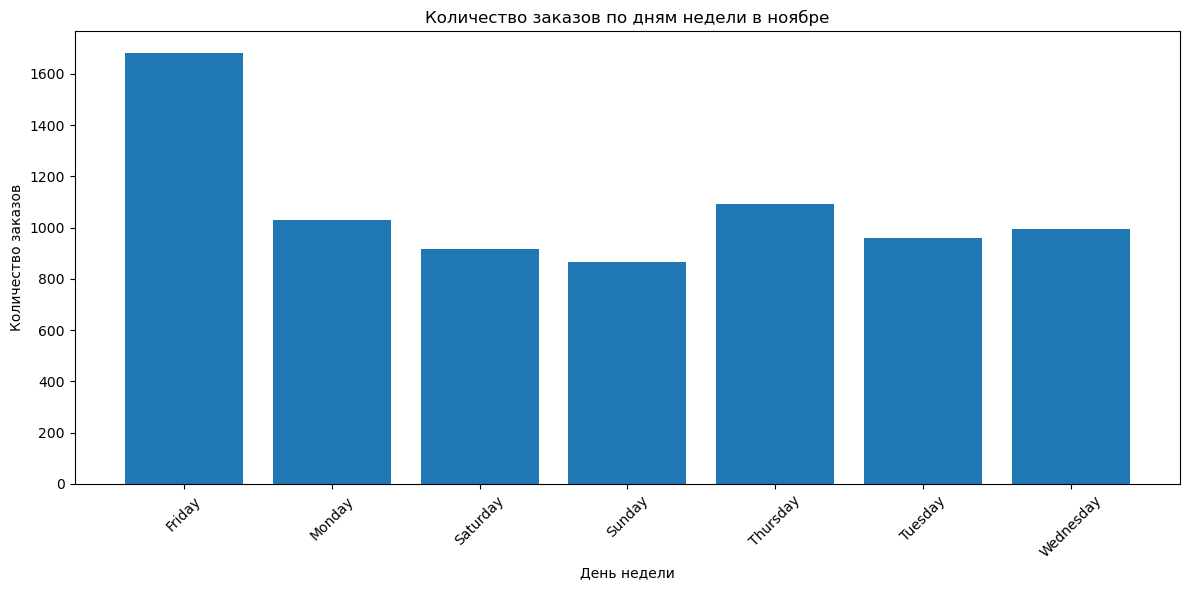

In [30]:
plt.figure(figsize=(12, 6))
plt.bar(novembers_orders_mean.index, novembers_orders_mean.values)
plt.title('Количество заказов по дням недели в ноябре')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Поиск акции конкретного дня

In [31]:
orders_11_11 = novembers_orders.loc[
    novembers_orders['order_purchase_timestamp'].dt.day == 11
]

In [32]:
daily_orders = (
    novembers_orders
    .groupby(novembers_orders['order_purchase_timestamp'].dt.day)
    .size()
)

In [33]:
daily_orders.sort_values(ascending=False).head()

order_purchase_timestamp
24    1176
25     499
27     403
26     391
28     380
dtype: int64

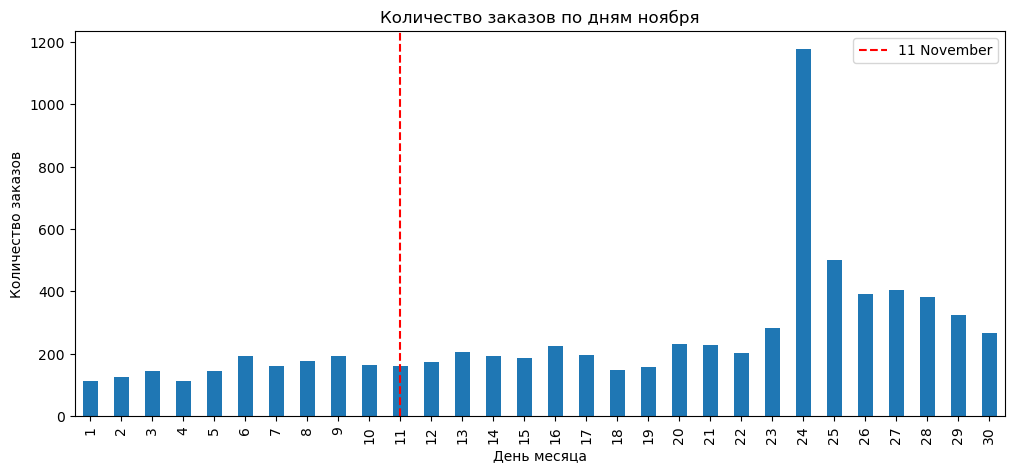

In [34]:
plt.figure(figsize=(12,5))
daily_orders.plot(kind='bar')
plt.axvline(x=10, color='red', linestyle='--', label='11 November')
plt.title('Количество заказов по дням ноября')
plt.xlabel('День месяца')
plt.ylabel('Количество заказов')
plt.legend()
plt.show()


## Выводы анализа пикового месяца продаж
* наибольшее количество заказов в ноябре было достигнуто засчет какой-то акции 24 ноября
* акция 11.11 если и проводилась, не повлияла на количество заказов
* анализ продаж в конкретных дней покупок не может проводиться точно, так как количество заказов по пятницам больше из-за продаж в конкретный день 24.11
* 24.11 совпадает со стартом Black Friday
Данных недостаточно, поэтому также проанализируем еще топ 2 и топ 3 месяца по продажам

## 2.3 Анализ двух крупных по продажам месяцев 01-2018 и 03-2018

In [35]:
top_montly_orders = orders_clean[
    ((orders_clean['order_purchase_timestamp'].dt.month == 1) | 
     (orders_clean['order_purchase_timestamp'].dt.month == 3))&
    (orders_clean['order_purchase_timestamp'].dt.year == 2018)
].copy()

### Анализ продаж по дням недели

In [36]:
top_montly_orders['weekday'] = top_montly_orders['order_purchase_timestamp'].dt.day_name()
top_montly_orders_weekday = top_montly_orders.groupby('weekday').size()

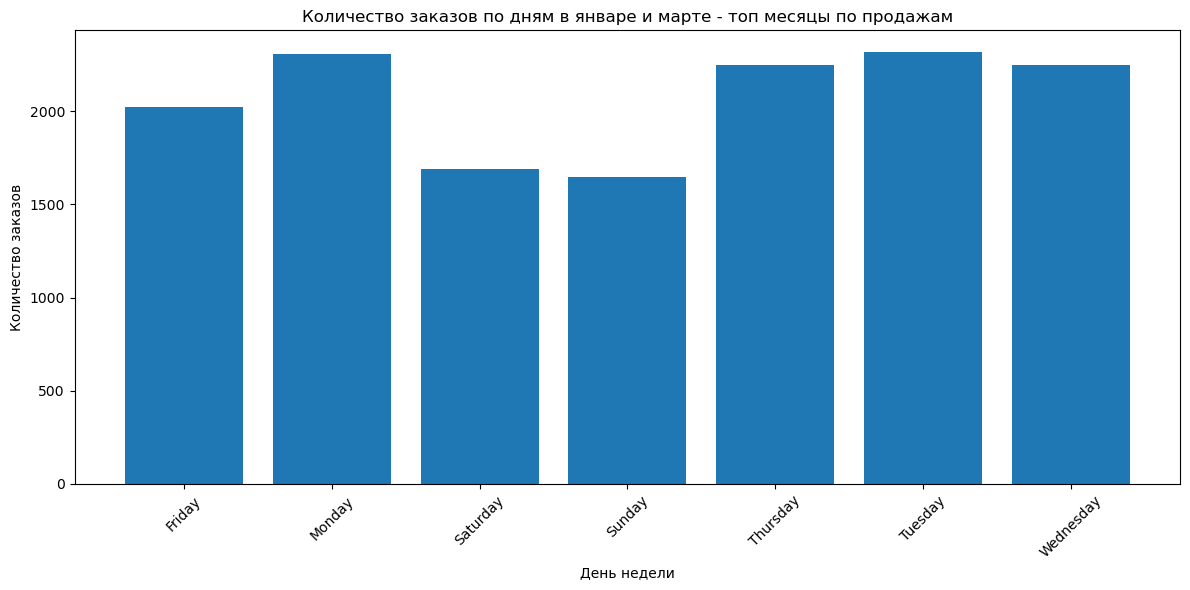

In [37]:
plt.figure(figsize=(12, 6))
plt.bar(top_montly_orders_weekday.index, top_montly_orders_weekday.values)
plt.title('Количество заказов по дням в январе и марте - топ месяцы по продажам')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Анализ продаж по часам в сутки

In [38]:
top_montly_orders['hour'] = top_montly_orders['order_purchase_timestamp'].dt.hour
top_montly_orders_hour =  top_montly_orders.groupby('hour').size()

In [39]:
top_montly_orders_hour

hour
0      343
1      162
2       65
3       42
4       22
5       24
6       78
7      174
8      395
9      723
10     967
11     978
12     846
13     915
14    1026
15     988
16     998
17     907
18     853
19     843
20     842
21     835
22     862
23     592
dtype: int64

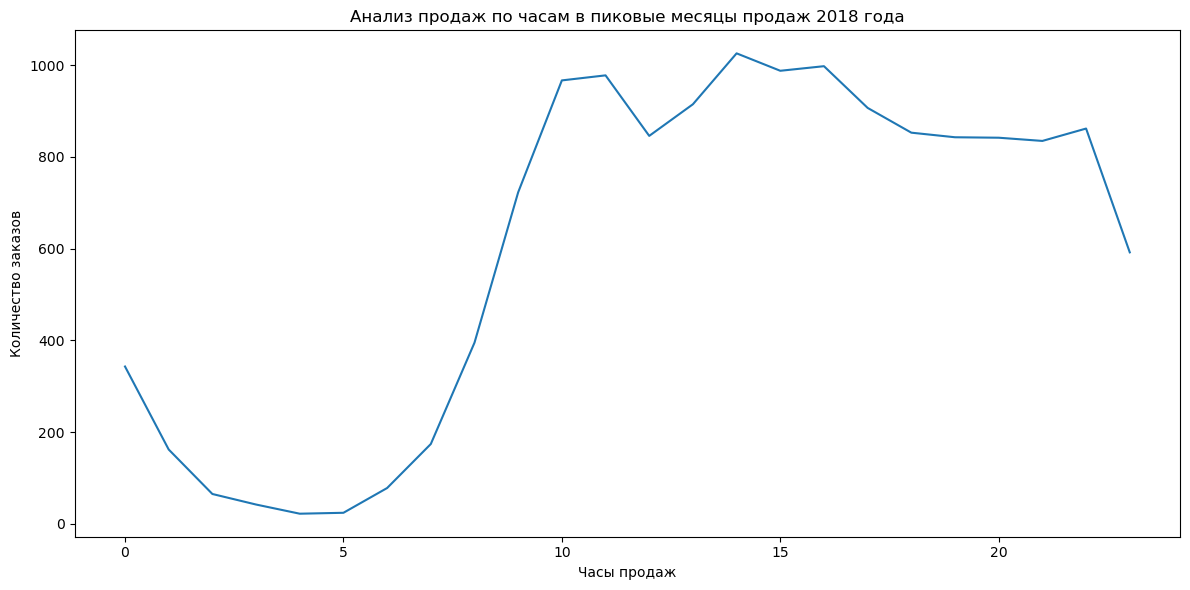

In [40]:
plt.figure(figsize=(12,6))
plt.plot(top_montly_orders_hour.index, top_montly_orders_hour.values)
plt.title('Анализ продаж по часам в пиковые месяцы продаж 2018 года')
plt.xlabel('Часы продаж')
plt.ylabel('Количество заказов')
plt.tight_layout()
plt.show()

## Выводы из анализа топ 2-3 месяцев по продажам: январь и март 2018
* У данной компании основыне продажи призодятся на будние дни первую половину недели
* Самые продаваемые часы с 10 до 12 и с 14 до 15 часов

## Рекомендации компании по продажам
* Компании стоит присмотреться к основным акциям 11.11, акциям к праздникам для продавцов
* Стоит приобщить покупателей к покупкам на выходных дополнительными акциями

# 3. Логистика

Как быстро обрабатываются заказы и доставляются клиентам?
Где происходят задержки?
Насколько реальная доставка совпадает с обещанной?

## 3.1. Время обработки заказа

In [41]:
orders_status_mean = orders_clean.copy()
orders_status_mean['time_to_approve_hours'] = (
    orders_status_mean['time_to_approve'].dt.total_seconds() / 3600
)

In [42]:
orders_status_mean['time_to_approve_hours'].describe()


count    99281.000000
mean        10.419094
std         26.038004
min          0.000000
25%          0.215000
50%          0.343333
75%         14.580833
max       4509.180556
Name: time_to_approve_hours, dtype: float64

In [43]:
processing_df = orders_status_mean[
    orders_status_mean['time_to_approve_hours'].notna()
    & (orders_status_mean['time_to_approve_hours'] >= 0)
    & (orders_status_mean['has_anomaly'] == False) 
] # Нормализуем данные для анализа, не берем данные с аномалиями


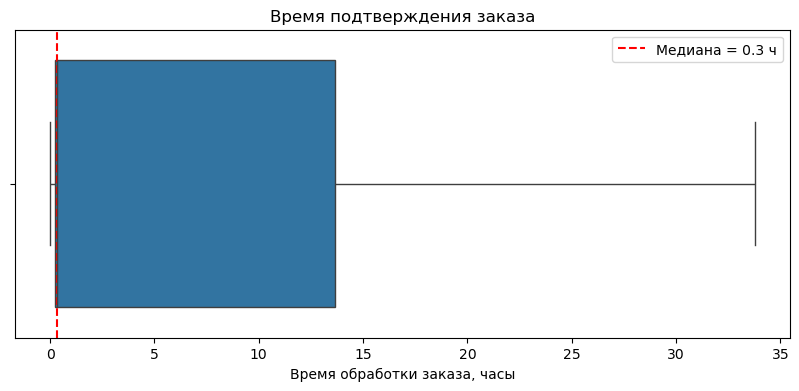

In [44]:
median = processing_df['time_to_approve_hours'].median()

plt.figure(figsize=(10, 4))
sns.boxplot(
    x=processing_df['time_to_approve_hours'],
    showfliers=False
)

plt.axvline(median, color='red', linestyle='--', label=f'Медиана = {median:.1f} ч')
plt.xlabel('Время обработки заказа, часы')
plt.title('Время подтверждения заказа')
plt.legend()
plt.show()


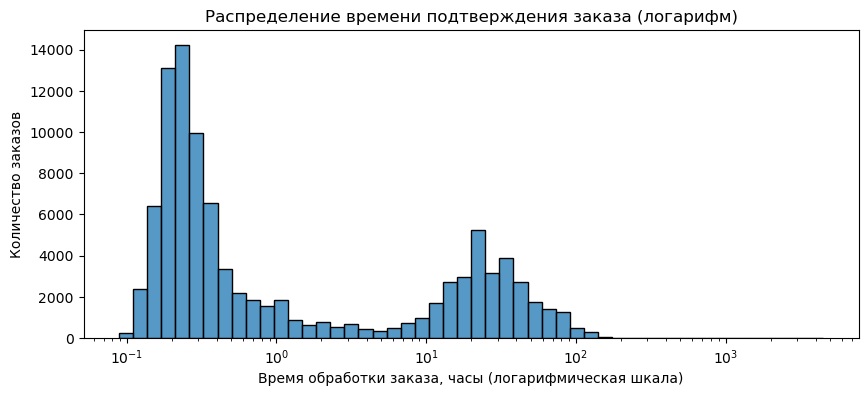

In [45]:
plt.figure(figsize=(10, 4))
sns.histplot(
    orders_status_mean['time_to_approve_hours'],
    bins=50,
    log_scale=True
)
plt.xlabel('Время обработки заказа, часы (логарифмическая шкала)')
plt.ylabel('Количество заказов')
plt.title('Распределение времени подтверждения заказа (логарифм)')
plt.show()


### Выводы по времени обработки заказа:
Большинство заказов подтверждаются в течение первых часов после оформления.
Медианное время обработки составляет 0.3 часа, при этом 75% заказов обрабатываются менее чем за 15 часов.
Это свидетельствует о достаточно быстрой реакции системы на оформление заказа.
Распределение времени подтверждения заказа также имеет выраженную правостороннюю асимметрию.
Основная масса заказов обрабатывается в течение первых часов, что формирует основной пик распределения.
Однако присутствует вторая группа заказов с существенно более длительным временем обработки, что может быть связано с отменами, нестандартными процессами или техническими задержками.

## 3.2 Время передачи в доставку

In [46]:
orders_status_mean['time_to_ship_days'] = (orders_status_mean['time_to_ship'].dt.total_seconds() / 86400)

In [47]:
processing_df = orders_status_mean[
    orders_status_mean['time_to_ship_days'].notna()
    & (orders_status_mean['time_to_ship_days'] >= 0)
    & (orders_status_mean['has_anomaly'] == False)
] # Нормализуем данные для обработки, не берем для анализа аномалии
processing_df['time_to_ship_days'].describe()

count    96262.000000
mean         2.857565
std          3.496091
min          0.000174
25%          0.901392
50%          1.851233
75%          3.622891
max        125.762569
Name: time_to_ship_days, dtype: float64

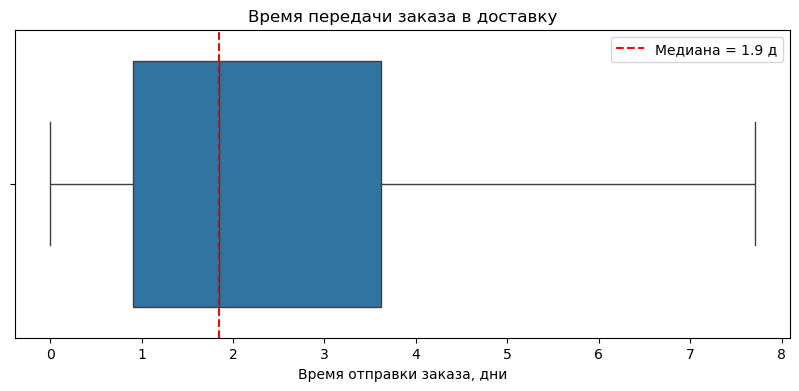

In [48]:
median = processing_df['time_to_ship_days'].median()

plt.figure(figsize=(10, 4))
sns.boxplot(
    x=processing_df['time_to_ship_days'],
    showfliers=False
)

plt.axvline(median, color='red', linestyle='--', label=f'Медиана = {median:.1f} д')
plt.xlabel('Время отправки заказа, дни')
plt.title('Время передачи заказа в доставку')
plt.legend()
plt.show()


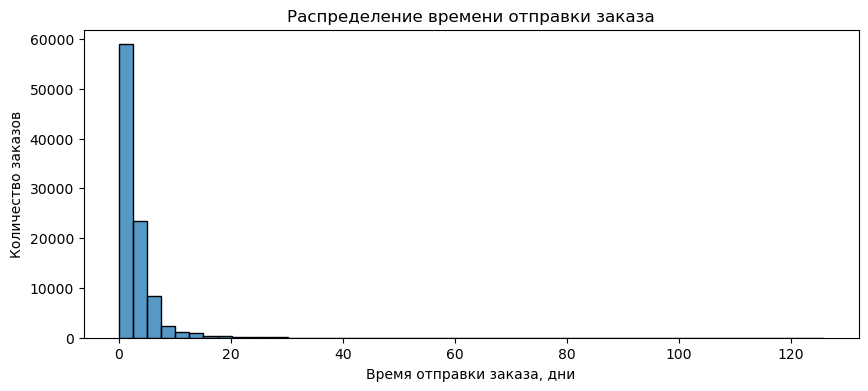

In [49]:
plt.figure(figsize=(10, 4))
sns.histplot(
    processing_df['time_to_ship_days'],
    bins=50,
)
plt.xlabel('Время отправки заказа, дни')
plt.ylabel('Количество заказов')
plt.title('Распределение времени отправки заказа')
plt.show()

### Выводы по времени отправки заказов:

Большинство заказов передается в доставку в первые пару дней от его подтверждения. Медианное время отправления около 2 дней, что указывает на стабильность работы службы отправки. 

Распределение имеет явную правосторонюю ассиметрию: при общей концентрации отправки заказов в первые дни после подвтреждения, наблюдается небольшой хвост заказов, подвтерждение которых происходило до 30 дней. Максимальный срок отправки 120 дней. Подобные значения встречаются редко, что указывает на возможные сбоилогистической системы, отмены, проблемы на стороне продавца. 

## 3.3 Время доставки заказа

In [50]:
orders_status_mean['time_to_deliver_days'] = (orders_status_mean['time_to_deliver'].dt.total_seconds() / 86400)

In [51]:
processing_df = orders_status_mean[
    orders_status_mean['time_to_deliver_days'].notna()
    & (orders_status_mean['time_to_deliver_days'] >= 0)
    & (orders_status_mean['has_anomaly'] == False)
] # Нормализуем данные для обработки, не берем для анализа аномалии, т.к. например есть аномалии с отрицательным количеством дней доставки
processing_df['time_to_deliver_days'].describe()

count    95102.000000
mean         9.364247
std          8.769030
min          0.000000
25%          4.111554
50%          7.110365
75%         12.057821
max        205.190972
Name: time_to_deliver_days, dtype: float64

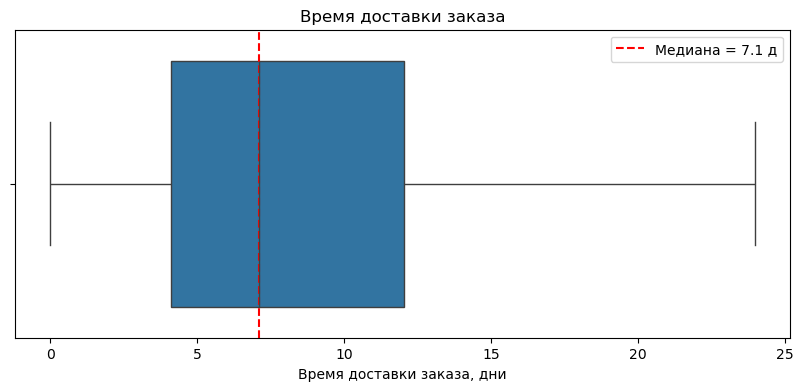

In [52]:
median = processing_df['time_to_deliver_days'].median()

plt.figure(figsize=(10, 4))
sns.boxplot(
    x=processing_df['time_to_deliver_days'],
    showfliers=False
)

plt.axvline(median, color='red', linestyle='--', label=f'Медиана = {median:.1f} д')
plt.xlabel('Время доставки заказа, дни')
plt.title('Время доставки заказа')
plt.legend()
plt.show()


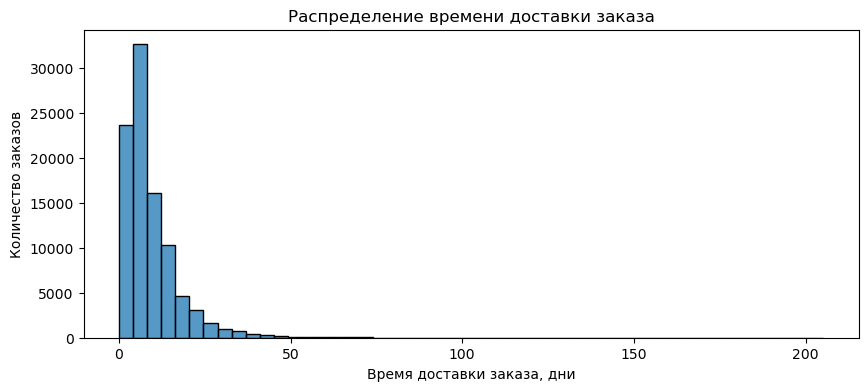

In [53]:
plt.figure(figsize=(10, 4))
sns.histplot(
    processing_df['time_to_deliver_days'],
    bins=50,
)
plt.xlabel('Время доставки заказа, дни')
plt.ylabel('Количество заказов')
plt.title('Распределение времени доставки заказа')
plt.show()

### Выводы по времени доставки:

Большинство заказов доставляется в интервале от 5 до 12 дней. Медианное время доставки составляет около 7 дней, что указывает на относительно стабильный и предсказуемый процесс доставки для основной массы заказов.

Распределение времени доставки имеет выраженную правостороннюю асимметрию: при общей концентрации заказов в короткие сроки наблюдается небольшой хвост заказов с существенно увеличенным временем доставки. Подобные значения являются редкими и, вероятно, связаны с логистическими сбоями, отменами, проблемами на стороне перевозчика или ошибками в данных.

Для описательной аналитики основное внимание следует уделять медианным и квартильным значениям, так как среднее значение чувствительно к экстремальным наблюдениям.

## 3.4. Фактическая vs обещанная доставка

In [54]:
orders_status_mean['time_to_actually_delivery'] = orders_status_mean['order_delivered_customer_date'] - orders_status_mean['order_estimated_delivery_date']

In [55]:
orders_status_mean['time_to_actually_delivery_days'] = (orders_status_mean['time_to_actually_delivery'].dt.total_seconds() / 86400)

In [56]:
orders_status_mean['being_late'] = (
    (orders_status_mean['order_delivered_customer_date'].notna()) &
    (orders_status_mean['order_estimated_delivery_date'].notna()) &
    (orders_status_mean['time_to_actually_delivery_days'] > 0)
)
orders_status_mean['being_late'].loc[orders_status_mean['being_late'] == True].count()

np.int64(7827)

In [57]:
orders_status_mean_being_late = orders_status_mean['being_late'].value_counts(normalize=True) * 100
orders_status_mean_being_late

being_late
False    92.129001
True      7.870999
Name: proportion, dtype: float64

In [58]:
orders_status_mean_being_late.index = [
    'Доставлены вовремя',
    'Доставлены с опозданием'
]

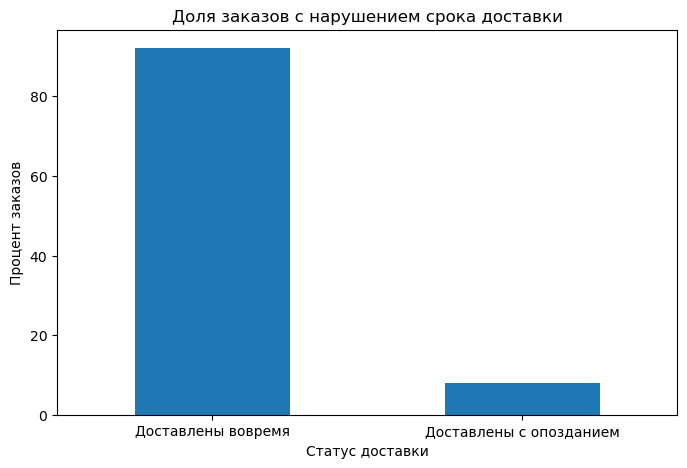

In [59]:
plt.figure(figsize=(8, 5))

orders_status_mean_being_late.plot(
    kind='bar'
)
plt.title('Доля заказов с нарушением срока доставки')
plt.ylabel('Процент заказов')
plt.xlabel('Статус доставки')
plt.xticks(rotation=0)
plt.show()


In [60]:
mean_delay_days = orders_status_mean.loc[
    orders_status_mean['time_to_actually_delivery_days'] > 0,
    'time_to_actually_delivery_days'
].mean()

round(mean_delay_days,2)

np.float64(9.55)

In [61]:
median_delay_days = orders_status_mean.loc[
    orders_status_mean['time_to_actually_delivery_days'] > 0,
    'time_to_actually_delivery_days'
].median()

round(median_delay_days, 2)


5.81

## Выводы Фактическая vs обещанная доставка:
По результатам анализа установлено, что около 7,9% заказов были доставлены клиентам с нарушением ожидаемого срока, в то время как более 92% заказов доставлены вовремя. Это свидетельствует о в целом стабильной работе логистической системы, однако наличие опозданий требует дополнительного анализа причин. В среднем заказы, доставленные с опозданием, задерживаются на 9-10 дней, при медианном значении 5-6 дней, что свидетельствует о том, что большинство задержек носят умеренный характер.

## Выводы по Descriptive Analytics

В ходе описательного анализа данных были изучены характеристики заказов, их распределение по времени, а также логистические показатели.

### 1. Распределение заказов
- Основная часть заказов имеет статус "delivered"
- Небольшая доля заказов находится в статусах "canceled", "unavailable" и "shipped"
- Были выявлены расхождения между статусами заказов и временными метками, что указывает на наличие неконсистентных данных

### 2. Временная динамика заказов
- Наблюдается рост количества заказов с течением времени
- Пик заказов приходится на ноябрь, что может быть связано с сезонными акциями (например, распродажи)
- Дополнительный анализ показал, что активность пользователей возрастает в определённые дни недели и часы

### 3. Логистика и время обработки заказов
- Большинство заказов подтверждаются в течение нескольких часов после оформления
- Распределение времени подтверждения имеет правостороннюю асимметрию, что связано с редкими задержками обработки

### 4. Время доставки
- Медианное время доставки составляет около 7 дней
- 50% заказов доставляются в диапазоне от 4 до 12 дней
- Распределение времени доставки имеет выраженную правостороннюю асимметрию
- Наблюдается наличие редких заказов с аномально большим временем доставки (до 200 дней)

### 5. Соблюдение сроков доставки
- Около 8% заказов доставляются с опозданием относительно ожидаемой даты
- При этом большинство заказов доставляются в срок
- Средняя задержка доставки составляет 9-10 дней 

### Общий вывод
Логистическая система платформы в целом функционирует стабильно: большинство заказов обрабатываются и доставляются в разумные сроки. Однако наличие правосторонней асимметрии и небольшой доли опозданий указывает на существование отдельных проблемных случаев, требующих дополнительного анализа.

# Глава 2. SQL Business Analysis

В данном разделе аналитика выполнена исключительно средствами SQL без использования pandas. Проводится бизнес-ориентированный анализ данных. Целью раздела является расчет ключевых метрик платформы: выручки, среднего чека, клиентской активности, повторных покупок, а также анализ эффективности категорий и продавцов.

# 1. Финансовые метрики платформы

## 1.1 Общая выручка платформы

**Бизнес-вопрос:**  
Какова общая выручка платформы за весь период?

In [62]:
querry = ''' SELECT ROUND(SUM(price + freight_value)::numeric, 2) AS total_revenue
FROM olist_order_items; '''
total_revenue = pd.read_sql(querry,engine)
total_revenue

,total_revenue
0,15843553.24


### Вывод

Общая выручка платформы составила 15 843 553. За анализируемый период совокупная выручка платформы составила 15,84 млн. Данный показатель отражает общий денежный оборот и служит базовой метрикой для оценки динамики роста бизнеса.

## 1.2 Выручка по месяцам

**Бизнес-вопрос:**  
Как менялась выручка по месяцам? Совпадают ли пики выручки с пиками количества заказов?

In [63]:
querry = '''SELECT 
    DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
    ROUND(SUM(oi.price + oi.freight_value)::numeric, 2) AS monthly_revenue
FROM olist_orders o
JOIN olist_order_items oi 
    ON o.order_id = oi.order_id
GROUP BY month
ORDER BY month;'''
monthly_revenue = pd.read_sql(querry,engine)
monthly_revenue

,month,monthly_revenue
0,2016-09-01,354.75
1,2016-10-01,56808.84
2,2016-12-01,19.62
3,2017-01-01,137188.49
4,2017-02-01,286280.62
5,2017-03-01,432048.59
6,2017-04-01,412422.24
7,2017-05-01,586190.95
8,2017-06-01,502963.04
9,2017-07-01,584971.62


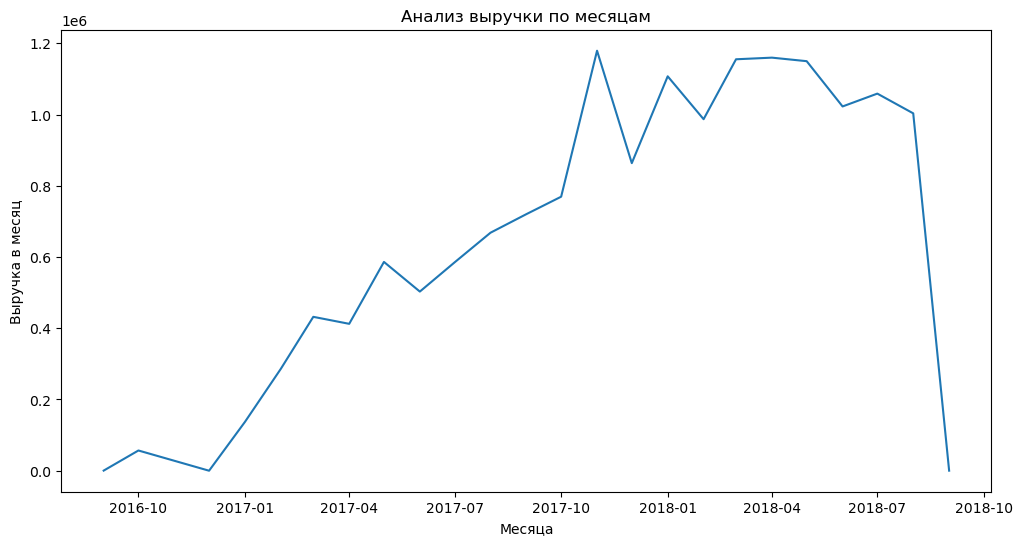

In [64]:
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['month'], monthly_revenue['monthly_revenue'])
plt.title('Анализ выручки по месяцам')
plt.xlabel('Месяца')
plt.ylabel('Выручка в месяц')
plt.show()

### Вывод
* 2016 год
  - Вероятнее всего совпадает с началом деятельности компании
  - Выручка минимальна
* 2017 год
  - С начала 2017 наблюдается устойчивый рост
  - Выручка увеличивается практически каждый месяц
  - Формируется восходящий тренд
  - Ноябрь-декабрь–2017 - заметный скачок. Вероятная сезонность (Black Friday - уже подтвержденная акция в количестве заказов, предновогодние продажи).
* 2018 год
  - Выручка держится около 1–1.2 млн в месяц
  - Платформа вышла на стабильный масштаб
  - Резкое снижение выручки в последнем месяце, вероятно, связано с неполной выгрузкой данных и не отражает реального падения бизнеса.

## 1.3 Средний чек (AOV)

**Бизнес-вопрос:**  
Каков средний чек заказа?
Как он меняется по месяцам?

In [65]:
querry = ''' WITH order_totals AS (
    SELECT 
        order_id,
        SUM(price + freight_value) AS order_total
    FROM olist_order_items
    GROUP BY order_id
)

SELECT 
    ROUND(AVG(order_total)::numeric, 2) AS avg_order_value
FROM order_totals;'''
avg_order_value = pd.read_sql(querry,engine)
avg_order_value

,avg_order_value
0,160.58


In [66]:
querry = ''' WITH order_totals AS (
    SELECT 
        o.order_id,
        DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
        SUM(oi.price + oi.freight_value) AS order_total
    FROM olist_orders o
    JOIN olist_order_items oi 
        ON o.order_id = oi.order_id
    GROUP BY o.order_id, month
)

SELECT 
    month,
    ROUND(AVG(order_total)::numeric, 2) AS avg_order_value
FROM order_totals
GROUP BY month
ORDER BY month;'''

avg_month_order_value = pd.read_sql(querry,engine)
avg_month_order_value

,month,avg_order_value
0,2016-09-01,118.25
1,2016-10-01,184.44
2,2016-12-01,19.62
3,2017-01-01,173.88
4,2017-02-01,165.19
5,2017-03-01,163.59
6,2017-04-01,172.49
7,2017-05-01,160.16
8,2017-06-01,156.35
9,2017-07-01,147.39


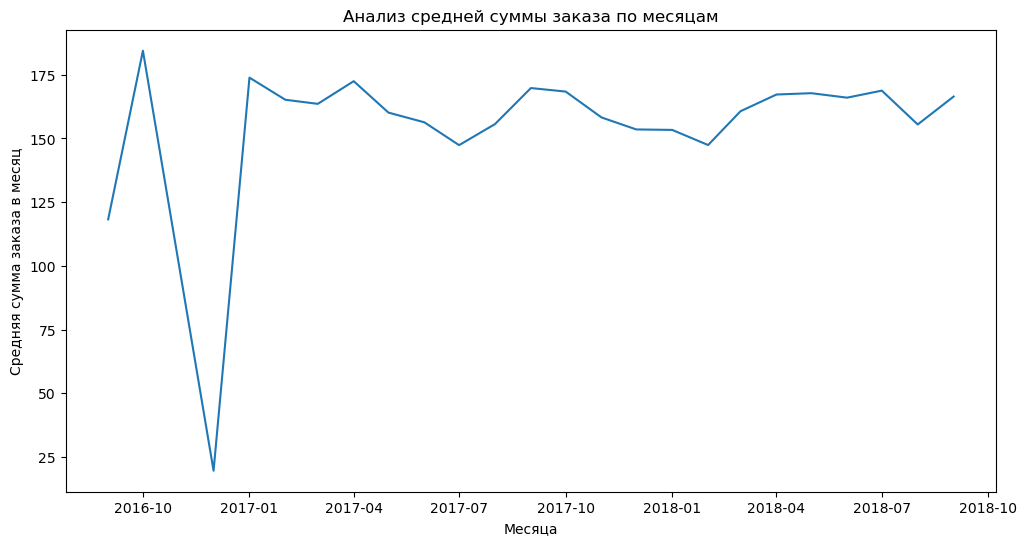

In [67]:
plt.figure(figsize=(12,6))
plt.plot(avg_month_order_value['month'], avg_month_order_value['avg_order_value'])
plt.title('Анализ средней суммы заказа по месяцам')
plt.xlabel('Месяца')
plt.ylabel('Средняя сумма заказа в месяц')
plt.show()

### Вывод
- Средний чек платформы стабилен и в течение 2017–2018 годов колеблется в диапазоне 150–175. Нет особо сильных выбросов, значит средний чек за все время 160 серьезная метрика.
- Значительного тренда роста не наблюдается, что свидетельствует о стабильном потребительском поведении.
- Рост общей выручки в анализируемый период обусловлен преимущественно увеличением количества заказов, а не ростом среднего чека.

# 2. Анализ клиентов

## 2.1 Количество уникальных покупателей

In [68]:
querry = '''SELECT COUNT(DISTINCT customer_unique_id) AS unique_customers
FROM olist_customers;'''
count_uniq_client =  pd.read_sql(querry,engine)
count_uniq_client

,unique_customers
0,96096


## 2.2 Повторные покупки (Retention proxy)

При расчёте повторных покупок использовался customer_unique_id, а не customer_id, поскольку в датасете Olist customer_id представляет собой технический идентификатор клиента в рамках конкретного заказа, тогда как customer_unique_id соответствует реальному пользователю.

In [69]:
querry = '''SELECT
    COUNT(*) AS total_customers,
    COUNT(CASE WHEN order_count > 1 THEN 1 END) AS repeat_customers,
    ROUND(
        COUNT(CASE WHEN order_count > 1 THEN 1 END) * 100.0 / COUNT(*),
        2
    ) AS repeat_rate_percent
FROM (
    SELECT
        c.customer_unique_id,
        COUNT(o.order_id) AS order_count
    FROM olist_orders o
    JOIN olist_customers c
        ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
) t;'''
retention_proxy =  pd.read_sql(querry,engine)
retention_proxy

,total_customers,repeat_customers,repeat_rate_percent
0,96096,2997,3.12


## 2.3 Среднее количество заказов на клиента

In [70]:
querry = '''SELECT
    ROUND(AVG(order_count), 2) AS avg_orders_per_customer
FROM (
    SELECT
        c.customer_unique_id,
        COUNT(o.order_id) AS order_count
    FROM olist_orders o
    JOIN olist_customers c
        ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
) t;'''
avg_count_orders_client =  pd.read_sql(querry,engine)
avg_count_orders_client

,avg_orders_per_customer
0,1.03


## 2.4 Распределение покупателей по числу заказов

In [71]:
querry = '''SELECT
    order_count,
    COUNT(*) AS customers_count
FROM (
    SELECT
        c.customer_unique_id,
        COUNT(o.order_id) AS order_count
    FROM olist_orders o
    JOIN olist_customers c
        ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
) t
GROUP BY order_count
ORDER BY order_count;'''
distribution =  pd.read_sql(querry,engine)
distribution

,order_count,customers_count
0,1,93099
1,2,2745
2,3,203
3,4,30
4,5,8
5,6,6
6,7,3
7,9,1
8,17,1


## Выводы по анализу клиентов

В ходе анализа клиентской базы были получены следующие результаты:

### 1. Размер клиентской базы
- Общее количество уникальных покупателей составляет **96 096 человек**, что свидетельствует о достаточно широкой пользовательской базе платформы

### 2. Повторные покупки
- Доля клиентов, совершивших более одного заказа, составляет **3.12%**
- Таким образом, подавляющее большинство пользователей совершают только одну покупку

### 3. Среднее количество заказов
- Среднее количество заказов на одного клиента составляет **1.03**
- Это подтверждает, что большинство пользователей не возвращаются для повторных покупок

### 4. Распределение клиентов по числу заказов
- Около **93 099 клиентов (~97%)** совершили только один заказ
- Значительно меньшее число пользователей совершают 2 и более покупок
- Доля клиентов с большим количеством заказов (5+) крайне мала

### Общий вывод
Платформа характеризуется низким уровнем удержания пользователей: большинство клиентов совершают разовую покупку и не возвращаются. Это может свидетельствовать о проблемах с удержанием аудитории, недостаточной лояльностью клиентов или специфике бизнес-модели (например, разовые покупки).

Полученные результаты указывают на потенциал для развития стратегий удержания клиентов и повышения повторных продаж.

# Вывод проекта

В рамках проекта был проведён комплексный анализ данных интернет-платформы электронной коммерции с использованием Python и SQL.

### 1. Общая динамика и статусы заказов
- Основная часть заказов имеет статус **"delivered"**, что указывает на завершённость большинства операций
- Однако присутствует небольшая доля заказов со статусами **"canceled"**, "unavailable" и "shipped"
- Были выявлены несоответствия между статусами и временными метками, что свидетельствует о наличии аномалий в данных

### 2. Временной анализ заказов
- Наблюдается рост количества заказов с течением времени
- Был выявлен выраженный пик заказов в ноябре, вероятно связанный с сезонными акциями
- Дополнительный анализ показал зависимость активности пользователей от дня недели и времени суток

### 3. Логистика и доставка
- Медианное время доставки составляет около **7 дней**
- Большинство заказов доставляется в диапазоне **5-12 дней**
- Распределение времени доставки имеет **правостороннюю асимметрию**, обусловленную редкими задержками
- Около **8% заказов** доставляются с опозданием
- Средняя задержка доставки составляет **9-10 дней**

В целом логистическая система функционирует стабильно, однако наблюдаются отдельные случаи значительных задержек

### 4. Финансовые показатели
- Проведён анализ выручки платформы
- Выявлены периоды роста, совпадающие с увеличением количества заказов
- Это подтверждает влияние сезонных факторов на финансовые показатели

### 5. Поведение клиентов
- Общее количество уникальных покупателей составляет более **96 000**
- Доля клиентов с повторными покупками составляет всего **3.12%**
- Среднее количество заказов на клиента **1.03**
- Около **97% пользователей** совершают только одну покупку

Это указывает на **низкий уровень удержания клиентов**

### 6. Общий вывод и рекомендации
На основе проведённого анализа можно выделить ключевые направления для развития платформы:

- оптимизация логистических процессов, поиск причин ошибок
- внедрение стратегий удержания клиентов (программы лояльности, персонализированные предложения)
- использование сезонных пиков спроса для увеличения продаж

В работе были использованы инструменты Python (pandas, matplotlib, seaborn) и SQL, что позволило провести комплексный и многогранный анализ данных.